In [1]:
import numpy as numpy
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
df = pd.read_csv('sim_data.csv')

In [28]:
t = df['Time'].to_numpy()
w_mech = df['Rads/s->mph'].to_numpy()
theta_m = df['Angle Sensor:Angle'].to_numpy()
back_emf_a = df['EBike Motor:Back EMF:1'].to_numpy()
back_emf_b = df['EBike Motor:Back EMF:2'].to_numpy()
back_emf_c = df['EBike Motor:Back EMF:3'].to_numpy()
hall_a = df['Hall Sensor:1'].to_numpy()
hall_b = df['Hall Sensor:2'].to_numpy()
hall_c = df['Hall Sensor:3'].to_numpy()

In [29]:
print(f"Array length: {len(t)}")

Array length: 60008


In [30]:
# Set time window in seconds
t0, t1 = 0.99, 1.25

def s(*arrays):
    """Slice all arrays to the time window [t0, t1]."""
    mask = (t >= t0) & (t <= t1)
    return [arr[mask] for arr in arrays]

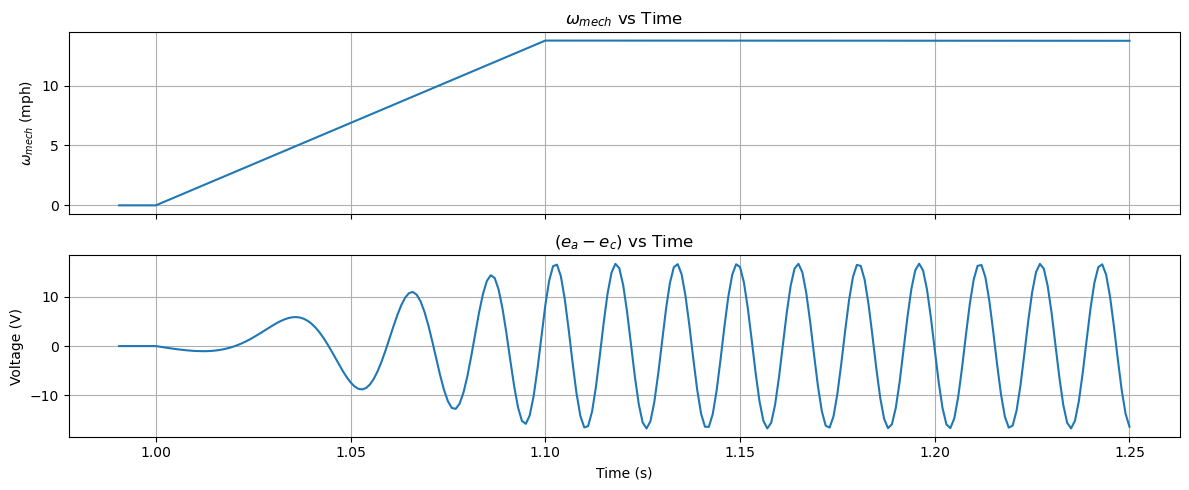

In [32]:
_t, _w, _theta, _ea, _eb, _ec, _ha, _hb, _hc = s(t, w_mech, theta_m, back_emf_a, back_emf_b, back_emf_c, hall_a, hall_b, hall_c)

# Figure 1: w_mech and ea-ec
fig1, ax1 = plt.subplots(2, 1, figsize=(12, 5), sharex=True)

ax1[0].plot(_t, _w)
ax1[0].set_ylabel(r'$\omega_{mech}$ (mph)')
ax1[0].set_title(r'$\omega_{mech}$ vs Time')
ax1[0].grid(True)

ax1[1].plot(_t, _ea - _ec)
ax1[1].set_ylabel('Voltage (V)')
ax1[1].set_title(r'$(e_a - e_c)$ vs Time')
ax1[1].set_xlabel('Time (s)')
ax1[1].grid(True)

fig1.tight_layout()

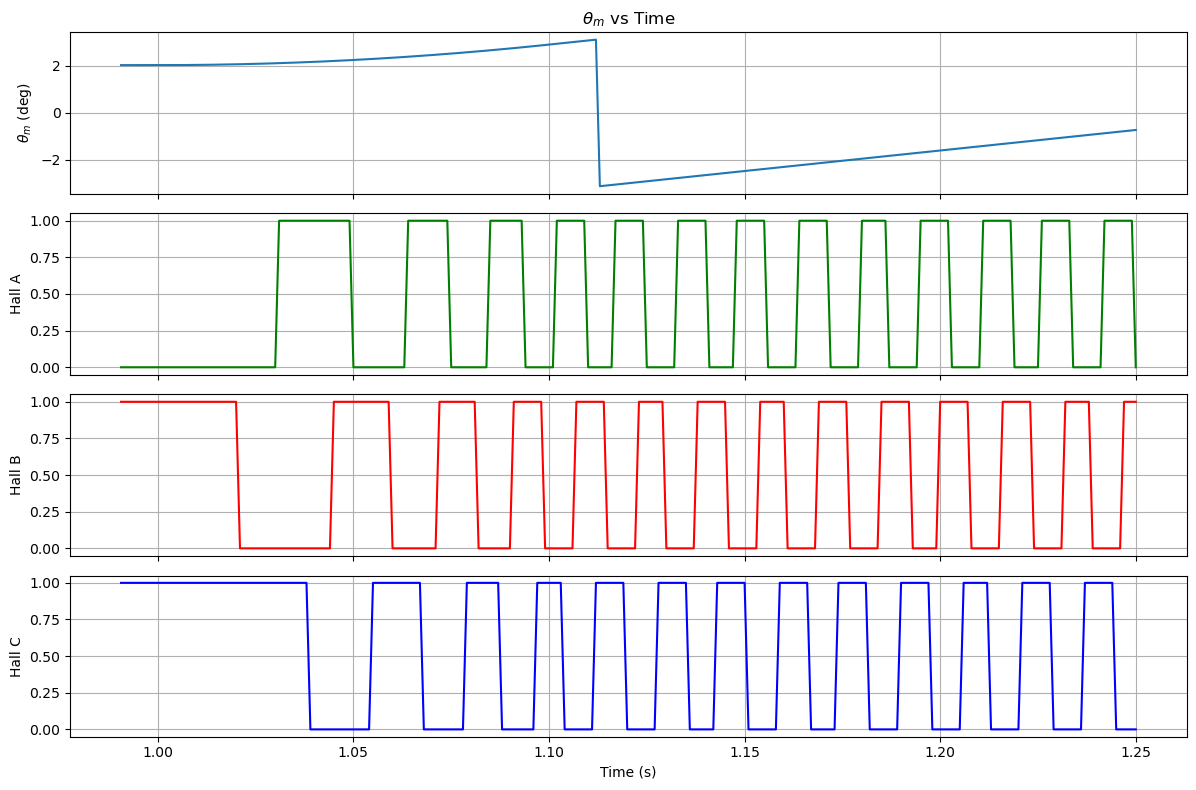

In [34]:
# Figure 2: theta_m and hall sensors
fig2, ax2 = plt.subplots(4, 1, figsize=(12, 8), sharex=True)

ax2[0].plot(_t, _theta)
ax2[0].set_ylabel(r'$\theta_m$ (deg)')
ax2[0].set_title(r'$\theta_m$ vs Time')
ax2[0].grid(True)

ax2[1].plot(_t, _ha, color='green')
ax2[1].set_ylabel('Hall A')
ax2[1].grid(True)

ax2[2].plot(_t, _hb, color='red')
ax2[2].set_ylabel('Hall B')
ax2[2].grid(True)

ax2[3].plot(_t, _hc, color='blue')
ax2[3].set_ylabel('Hall C')
ax2[3].set_xlabel('Time (s)')
ax2[3].grid(True)

fig2.tight_layout()
plt.show()

In [35]:
df_vac = pd.read_csv('v-ac peak.csv', skiprows=20)

t_osc = df_vac['TIME'].to_numpy()
eac = df_vac['CH1'].to_numpy()